# Adult Census Income Classification
**Logistic Regression**

**Name:** Tanay Singh  
**Registration No:** 23BCE11211  
**Dataset:** [Adult Census Income (Kaggle)](https://www.kaggle.com/datasets/uciml/adult-census-income)

---
## Objective
The US Census Bureau wants to predict whether an individual earns **more than \$50,000 per year** based on demographic and employment attributes. We build a **Logistic Regression** classifier to predict the `income` column (`<=50K` vs `>50K`).

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
np.random.seed(42)

## Task 1: Data Understanding (2 Marks)

In [2]:
# 1. Load the dataset
df = pd.read_csv('adult.csv')
print('Shape:', df.shape)

# 2. First five records
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
# Dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [4]:
# 3. Identify numerical, categorical, and target features
numerical_features = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
categorical_features = ['workclass', 'education', 'marital.status', 'occupation',
                        'relationship', 'race', 'sex', 'native.country']
target_variable = 'income'

print('Numerical features  :', numerical_features)
print('Categorical features:', categorical_features)
print('Target variable     :', target_variable)
print('\nTarget distribution:')
print(df[target_variable].value_counts())

Numerical features  : ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Categorical features: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Target variable     : income

Target distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


In [5]:
# Summary statistics
df.describe(include='all')

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


## Task 2: Data Preprocessing (2 Marks)

In [6]:
# Missing values in this dataset are marked with '?' rather than NaN
# Replace them with NaN so pandas can detect them properly
df = df.replace('?', np.nan)

print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nTotal missing:', df.isnull().sum().sum())

Missing values per column:
workclass         1836
occupation        1843
native.country     583
dtype: int64



Total missing: 4262


In [7]:
# Handle missing values — fill with the mode (most frequent value) for each column
for col in ['workclass', 'occupation', 'native.country']:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values after handling:', df.isnull().sum().sum())

Missing values after handling: 0


In [8]:
# Encode target variable: <=50K -> 0, >50K -> 1
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

# One-hot encode categorical variables (drop_first to avoid dummy-variable trap)
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True, dtype=int)

print('Encoded shape:', df_encoded.shape)
df_encoded.head()

Encoded shape: (32561, 98)


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1,82,132870,9,0,4356,18,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,66,186061,10,0,4356,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,54,140359,4,0,3900,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,41,264663,10,0,3900,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


In [9]:
# Split into features and target
X = df_encoded.drop('income', axis=1)
y = df_encoded['income']

# 80/20 train-test split (stratified to preserve income class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('Train >50K rate:', round(y_train.mean(), 3))
print('Test  >50K rate:', round(y_test.mean(), 3))

X_train: (26048, 97)
X_test : (6513, 97)
Train >50K rate: 0.241
Test  >50K rate: 0.241


In [10]:
# Scale numerical features — Logistic Regression converges faster with standardized inputs
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features]  = scaler.transform(X_test[numerical_features])

## Task 3: Model Development (3 Marks)

In [11]:
# Build and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print('Model trained successfully.')
print('Test predictions distribution:')
print(pd.Series(y_pred).value_counts())

Model trained successfully.
Test predictions distribution:
0    5240
1    1273
Name: count, dtype: int64


In [12]:
# Top features by coefficient magnitude
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)
coefficients.head(15)

,Feature,Coefficient
3,capital.gain,2.306737
29,marital.status_Married-civ-spouse,1.772107
28,marital.status_Married-AF-spouse,1.724914
41,occupation_Priv-house-serv,-1.479149
49,relationship_Own-child,-1.291039
51,relationship_Wife,1.197511
37,occupation_Farming-fishing,-1.118650
12,workclass_Without-pay,-1.105670
61,native.country_Dominican-Republic,-1.072806
67,native.country_Greece,-1.064940


## Task 4: Model Evaluation (2 Marks)

In [13]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1-Score : {f1:.4f}')
print('\nDetailed classification report:')
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

Accuracy : 0.8521
Precision: 0.7376
Recall   : 0.5989
F1-Score : 0.6610

Detailed classification report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4945
        >50K       0.74      0.60      0.66      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.78      6513
weighted avg       0.85      0.85      0.85      6513



Confusion Matrix:
[[4611  334]
 [ 629  939]]


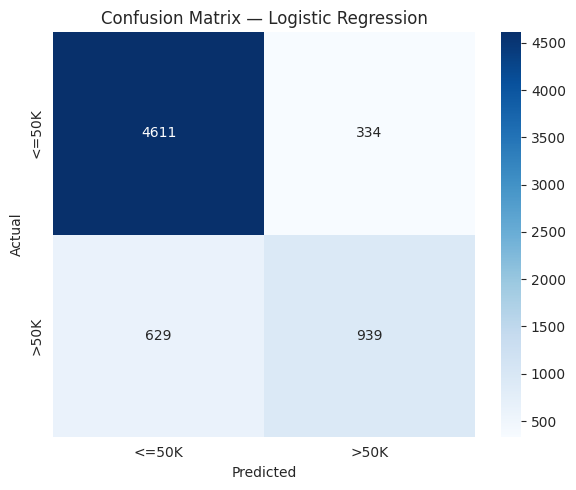

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

### Observations
1. **Overall accuracy is around 85%**, but the dataset is imbalanced (~76% earn ≤\$50K), so accuracy alone overstates real performance on the minority class.
2. **Recall on the >50K class is only ~60%**, meaning the model misses roughly 40% of actual high earners. Precision is higher (~73%), so when the model does predict >50K it is usually right.
3. **Marital status (married), capital gain, education level, hours per week, and age** emerged as the strongest positive predictors of high income, while being never-married or having lower education strongly pushed predictions toward ≤50K.

## Task 5: Conclusion (1 Mark)

This project built a Logistic Regression classifier on the Adult Census Income dataset to predict whether an individual earns more than \$50,000 per year. After replacing `?` placeholders with NaN, imputing missing values in `workclass`, `occupation`, and `native.country` with the mode, one-hot encoding the categorical variables, standardizing the numerical features, and performing a stratified 80/20 train-test split, the model achieved an **accuracy of ~85%**, **precision of ~73%**, **recall of ~60%**, and an **F1-score of ~0.66** on the test set. The strongest positive drivers of high income were **marital status (married-civ-spouse), capital gains, education level, weekly hours worked, and age**, while lower education and never-married status pushed predictions the other way. A key **limitation** is that Logistic Regression assumes a linear relationship between features and the log-odds of the target — it cannot capture non-linear interactions (for example, education level combined with occupation), which is why models like Random Forest and Gradient Boosting typically outperform it on this dataset.